In [84]:
# !pip install xlrd

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'Malgun Gothic'

# 데이터 로드
df = pd.read_excel('./data1/sanbul.xls',engine="xlrd",skiprows=2)
df = df.sort_values(by='발생일시_년').reset_index()

In [86]:
# 필요없는 값 제거 (논의가 필요함)
df = df.drop(columns=['index','발생일시_시간','발생일시_요일','진화종료시간_시간','발생장소_읍면','발생장소_동리','발생원인_구분','발생원인_세부원인','발생원인_기타','발생장소_시군구','발생장소_관서'],axis=1)

In [87]:
# 산불이 많이 일어난 지역 확인
df.groupby('발생장소_시도').count().sort_values('발생일시_년',ascending=False)

,발생일시_년,발생일시_월,발생일시_일,진화종료시간_년,진화종료시간_월,진화종료시간_일,피해면적_합계
발생장소_시도,,,,,,,
경기,1250,1250,1250,1250,1250,1250,1250
경북,831,831,831,831,831,831,831
강원,667,667,667,667,667,667,667
경남,510,510,510,510,510,510,510
충남,430,430,430,430,430,430,430
전남,366,366,366,366,366,366,366
전북,274,274,274,274,274,274,274
충북,243,243,243,243,243,243,243
인천,147,147,147,147,147,147,147


In [88]:
# 시작일시 통합 (datetime)
df['시작_일시'] = pd.to_datetime(
    df[['발생일시_년', '발생일시_월', '발생일시_일']].rename(
        columns={'발생일시_년':'year', '발생일시_월':'month', '발생일시_일':'day'}
    ),
    errors='coerce'
)

# 종료일시 통합 (datetime)

df['종료_일시'] = pd.to_datetime(
    df[['진화종료시간_년', '진화종료시간_월', '진화종료시간_일']].rename(
        columns={'진화종료시간_년':'year', '진화종료시간_월':'month', '진화종료시간_일':'day'}
    ),
    errors='coerce'
)

# 지속일시 컬럼 추가
df['지속_일시'] = df['종료_일시'] - df['시작_일시']
df

,발생일시_년,발생일시_월,발생일시_일,진화종료시간_년,진화종료시간_월,진화종료시간_일,발생장소_시도,피해면적_합계,시작_일시,종료_일시,지속_일시
0,2016,1,16,2016,1,17,경기,0.50,2016-01-16,2016-01-17,1 days
1,2016,1,16,2016,1,17,인천,0.33,2016-01-16,2016-01-17,1 days
2,2016,1,17,2016,1,17,경북,0.01,2016-01-17,2016-01-17,0 days
3,2016,1,18,2016,1,18,경기,0.20,2016-01-18,2016-01-18,0 days
4,2016,1,19,2016,1,19,강원,3.00,2016-01-19,2016-01-19,0 days
...,...,...,...,...,...,...,...,...,...,...,...
5286,2025,12,29,2025,12,29,강원,2.10,2025-12-29,2025-12-29,0 days
5287,2025,12,30,2025,12,30,전남,0.15,2025-12-30,2025-12-30,0 days
5288,2025,12,31,2025,12,31,경북,0.30,2025-12-31,2025-12-31,0 days
5289,2025,12,6,2025,12,6,경북,0.08,2025-12-06,2025-12-06,0 days


In [89]:
df_nong = pd.read_csv('./data1/nongji.csv',encoding='CP949')
df_nong = df_nong[df_nong['시도별(1)'] != '전국']

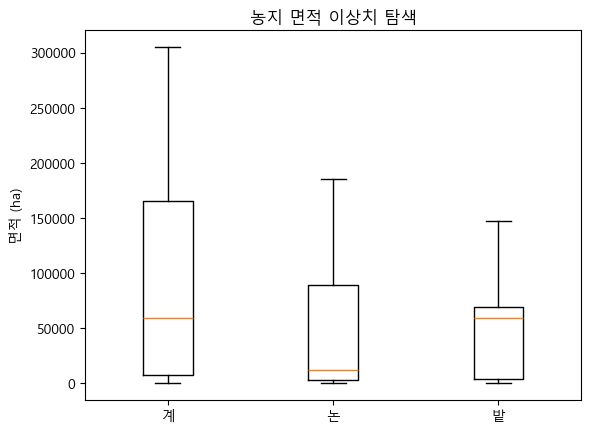

In [90]:
# 이상치 확인   
target_cols = ['계', '논', '밭']
plt.boxplot(df_nong[target_cols])

# 그래프 설정
plt.xticks([1, 2, 3], target_cols) # x축 라벨을 컬럼명으로 변경
plt.title('농지 면적 이상치 탐색')
plt.ylabel('면적 (ha)')
plt.show()

In [91]:
# 이상치 확인 후 다시 로드
df_nong = pd.read_csv('./data1/nongji.csv',encoding='CP949')
df_nong['시도별(1)'].unique()

array(['전국', '서울특별시', '부산광역시', '대구광역시', '인천광역시', '광주광역시', '대전광역시',
       '울산광역시', '세종특별자치시', '경기도', '강원도', '충청북도', '충청남도', '전라북도', '전라남도',
       '경상북도', '경상남도', '제주도'], dtype=object)

In [92]:
# 시도 이름 변경
df_nong['시도별(1)'] = df_nong['시도별(1)'].replace({'서울특별시':'서울', '부산광역시':'부산', '대구광역시':'대구', '인천광역시':'인천', '광주광역시':'광주', '대전광역시':'대전',
       '울산광역시':'울산', '세종특별자치시':'세종', '경기도':'경기', '강원도':'강원', '충청북도':'충북', '충청남도':'충남', '전라북도':'전북', '전라남도':'전남',
       '경상북도':'경북', '경상남도':'경남', '제주도':'제주'})

In [93]:
# merge를 위해 이름 변경
df_nong = df_nong.rename(columns={'시도별(1)':'발생장소_시도'})


In [94]:
# 1. 전국 데이터만 df로 만들기
df_national = df_nong[df_nong['발생장소_시도'] == '전국'][['시점', '논', '밭']].rename(columns={'논': '전국_논', '밭': '전국_밭'})

# 2. '전국' 데이터가 제외된 지역 데이터프레임과 병합
df_nong = df_nong[df_nong['발생장소_시도'] != '전국']
df_nong
df_merged = pd.merge(df_nong, df_national, on='시점', how='left')

# 비율 *100 이후 반올림
df_merged['논_비율'] = (df_merged['논'] / df_merged['전국_논']) * 100
df_merged['밭_비율'] = (df_merged['밭'] / df_merged['전국_밭']) * 100

# 결과 확인
df_nong = df_merged.drop(columns=['전국_논', '전국_밭'])
df_nong

,시점,발생장소_시도,계,논,밭,논_비율,밭_비율
0,2015,서울,475.994211,175.924885,300.069326,0.019371,0.038928
1,2015,부산,6008.225714,3490.214665,2518.011049,0.384303,0.326663
2,2015,대구,8290.759326,3864.730822,4426.028504,0.425540,0.574191
3,2015,인천,20114.191694,13444.792711,6669.398983,1.480388,0.865224
4,2015,광주,10261.155237,6615.381880,3645.773357,0.728411,0.472968
...,...,...,...,...,...,...,...
165,2024,전북,188388.696100,121610.269600,66778.426500,15.980086,8.980383
166,2024,전남,273506.692200,161877.761900,111628.930300,21.271398,15.011892
167,2024,경북,235889.213900,97926.500100,137962.713800,12.867942,18.553268
168,2024,경남,134242.769200,65279.506600,68963.262600,8.577993,9.274201


In [95]:
# merge를 위해 컬럼명 통일
df_nong = df_nong.rename(columns={'시점':'발생일시_년'})
df_nong

,발생일시_년,발생장소_시도,계,논,밭,논_비율,밭_비율
0,2015,서울,475.994211,175.924885,300.069326,0.019371,0.038928
1,2015,부산,6008.225714,3490.214665,2518.011049,0.384303,0.326663
2,2015,대구,8290.759326,3864.730822,4426.028504,0.425540,0.574191
3,2015,인천,20114.191694,13444.792711,6669.398983,1.480388,0.865224
4,2015,광주,10261.155237,6615.381880,3645.773357,0.728411,0.472968
...,...,...,...,...,...,...,...
165,2024,전북,188388.696100,121610.269600,66778.426500,15.980086,8.980383
166,2024,전남,273506.692200,161877.761900,111628.930300,21.271398,15.011892
167,2024,경북,235889.213900,97926.500100,137962.713800,12.867942,18.553268
168,2024,경남,134242.769200,65279.506600,68963.262600,8.577993,9.274201


In [96]:
# merge
df_final = df.merge(df_nong,on=['발생일시_년','발생장소_시도'])
df_final

,발생일시_년,발생일시_월,발생일시_일,진화종료시간_년,진화종료시간_월,진화종료시간_일,발생장소_시도,피해면적_합계,시작_일시,종료_일시,지속_일시,계,논,밭,논_비율,밭_비율
0,2016,1,16,2016,1,17,경기,0.50,2016-01-16,2016-01-17,1 days,169435.0000,93216.0000,76219.0000,10.406603,10.191613
1,2016,1,16,2016,1,17,인천,0.33,2016-01-16,2016-01-17,1 days,19511.0000,12720.0000,6791.0000,1.420057,0.908058
2,2016,1,17,2016,1,17,경북,0.01,2016-01-17,2016-01-17,0 days,268461.0000,125846.0000,142615.0000,14.049405,19.069746
3,2016,1,18,2016,1,18,경기,0.20,2016-01-18,2016-01-18,0 days,169435.0000,93216.0000,76219.0000,10.406603,10.191613
4,2016,1,19,2016,1,19,강원,3.00,2016-01-19,2016-01-19,0 days,104330.0000,37763.0000,66567.0000,4.215849,8.900998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4827,2024,10,13,2024,10,13,경기,0.01,2024-10-13,2024-10-13,0 days,146381.8925,76489.0943,69892.7982,10.050979,9.399205
4828,2024,11,24,2024,11,24,인천,0.02,2024-11-24,2024-11-24,0 days,17241.8595,12168.7233,5073.1362,1.599020,0.682237
4829,2024,12,18,2024,12,18,경기,0.13,2024-12-18,2024-12-18,0 days,146381.8925,76489.0943,69892.7982,10.050979,9.399205
4830,2024,12,18,2024,12,18,강원,0.23,2024-12-18,2024-12-18,0 days,99531.0154,29895.7937,69635.2217,3.928429,9.364566


In [97]:
# 2025년 수치가 없어 2024년 수치로 대체
df_2024 = df_nong[df_nong['발생일시_년'] == 2024].copy()
df_2024['발생일시_년'] = 2025
df_nong = pd.concat([df_nong, df_2024], ignore_index=True)

In [98]:
df_nong

,발생일시_년,발생장소_시도,계,논,밭,논_비율,밭_비율
0,2015,서울,475.994211,175.924885,300.069326,0.019371,0.038928
1,2015,부산,6008.225714,3490.214665,2518.011049,0.384303,0.326663
2,2015,대구,8290.759326,3864.730822,4426.028504,0.425540,0.574191
3,2015,인천,20114.191694,13444.792711,6669.398983,1.480388,0.865224
4,2015,광주,10261.155237,6615.381880,3645.773357,0.728411,0.472968
...,...,...,...,...,...,...,...
182,2025,전북,188388.696100,121610.269600,66778.426500,15.980086,8.980383
183,2025,전남,273506.692200,161877.761900,111628.930300,21.271398,15.011892
184,2025,경북,235889.213900,97926.500100,137962.713800,12.867942,18.553268
185,2025,경남,134242.769200,65279.506600,68963.262600,8.577993,9.274201


In [99]:
df_final

,발생일시_년,발생일시_월,발생일시_일,진화종료시간_년,진화종료시간_월,진화종료시간_일,발생장소_시도,피해면적_합계,시작_일시,종료_일시,지속_일시,계,논,밭,논_비율,밭_비율
0,2016,1,16,2016,1,17,경기,0.50,2016-01-16,2016-01-17,1 days,169435.0000,93216.0000,76219.0000,10.406603,10.191613
1,2016,1,16,2016,1,17,인천,0.33,2016-01-16,2016-01-17,1 days,19511.0000,12720.0000,6791.0000,1.420057,0.908058
2,2016,1,17,2016,1,17,경북,0.01,2016-01-17,2016-01-17,0 days,268461.0000,125846.0000,142615.0000,14.049405,19.069746
3,2016,1,18,2016,1,18,경기,0.20,2016-01-18,2016-01-18,0 days,169435.0000,93216.0000,76219.0000,10.406603,10.191613
4,2016,1,19,2016,1,19,강원,3.00,2016-01-19,2016-01-19,0 days,104330.0000,37763.0000,66567.0000,4.215849,8.900998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4827,2024,10,13,2024,10,13,경기,0.01,2024-10-13,2024-10-13,0 days,146381.8925,76489.0943,69892.7982,10.050979,9.399205
4828,2024,11,24,2024,11,24,인천,0.02,2024-11-24,2024-11-24,0 days,17241.8595,12168.7233,5073.1362,1.599020,0.682237
4829,2024,12,18,2024,12,18,경기,0.13,2024-12-18,2024-12-18,0 days,146381.8925,76489.0943,69892.7982,10.050979,9.399205
4830,2024,12,18,2024,12,18,강원,0.23,2024-12-18,2024-12-18,0 days,99531.0154,29895.7937,69635.2217,3.928429,9.364566


In [100]:
df_sanrim = pd.read_csv('./data1/sanrim_myunjeok.csv', encoding='CP949',skiprows=1)
df_dosi = pd.read_csv('./data1/dosimyunjeok.csv', encoding='CP949')
df_sanrim = df_sanrim.drop(0)
df_sanrim = df_sanrim.iloc[:, :7]
df_sanrim = df_sanrim[df_sanrim['행정구역별(2)']=='소계'].reset_index(drop=True)

# 2020년 컬럼을 숫자로 변환
df_sanrim['2020'] = pd.to_numeric(df_sanrim['2020'], errors='coerce')

# 0으로 채우고 정수형 변환
df_sanrim['2020'] = df_sanrim['2020'].fillna(0).astype(int)

for y in ['2021', '2022', '2023', '2024']:
    df_sanrim[y] = df_sanrim['2020']
df_sanrim = df_sanrim.drop(df_sanrim.columns[1], axis=1)
df_sanrim['행정구역별(1)'] = df_sanrim['행정구역별(1)'].replace({'전라북도': '전북특별자치도'})
df_sanrim



,행정구역별(1),2016,2017,2018,2019,2020,2021,2022,2023,2024
0,서울특별시,15486,15486,15486,15486,15486,15486,15486,15486,15486
1,부산광역시,35386,35386,35386,35386,34926,34926,34926,34926,34926
2,대구광역시,48705,48705,48705,48705,48338,48338,48338,48338,48338
3,인천광역시,40450,40625,39978,39978,39373,39373,39373,39373,39373
4,광주광역시,19244,19244,19244,19244,18944,18944,18944,18944,18944
5,대전광역시,29928,29928,29928,29928,26206,26206,26206,26206,26206
6,울산광역시,63429,68671,68671,68671,68001,68001,68001,68001,68001
7,세종특별자치시,25288,25288,25288,25288,24849,24849,24849,24849,24849
8,경기도,520068,520068,520068,520068,512105,512105,512105,512105,512105
9,강원특별자치도,1371643,1371643,1371643,1371643,1354948,1354948,1354948,1354948,1354948


In [101]:
# 전국 제외
df_dosi = df_dosi.drop(0).reset_index(drop=True)
df_dosi

,소재지(시군구)별,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,서울특별시,606114295,605597491,605569314,605512630,605680193,605680264,605672952,605673772,605748896
1,부산광역시,940825056,940825056,940825058,940825058,940825055,940825971,940844566,940825056,940825056
2,대구광역시,797969025,798003179,797919337,799328917,799299015,799509757,801033747,808195732,808209312
3,인천광역시,580154144,580144347,579740346,529642905,529650659,529699653,527855326,512816173,513676030
4,광주광역시,481554450,480047663,480053767,480002734,480081726,479978979,479890096,479838049,479818783
5,대전광역시,495546287,495546171,495818299,496123890,496123890,496123890,496123890,496123890,496123742
6,울산광역시,755545355,755551876,755545356,755545353,761731893,764204857,764212886,671649337,677663085
7,세종특별자치시,140971433,141468621,142715907,142715907,142495482,143324836,141833041,141833041,142568912
8,경기도,3367486105,3371075153,3376013136,3377274307,3378712218,3385441488,3386898994,3370827754,3397055790
9,강원특별자치도,1027198470,1027228237,1028778399,1028522877,1029687366,1030004376,1030008274,1004738631,1005224851


In [102]:
# 지역 컬럼명 맞추기
san = df_sanrim.set_index('행정구역별(1)')
dosi = df_dosi.set_index('소재지(시군구)별')

# 연도 컬럼만 고르기
years = san.columns.intersection(dosi.columns)

# 3) 숫자형 변환
san[years] = san[years].apply(pd.to_numeric, errors='coerce')
dosi[years] = dosi[years].apply(pd.to_numeric, errors='coerce')

# 4) 0으로 나누는 것 방지
ratio = san[years].div(dosi[years].replace(0, np.nan))

# 5) 다시 컬럼으로 지역 넣기
ratio = ratio.reset_index().rename(columns={'index':'행정구역'})
ratio = ratio.dropna()
ratio


,행정구역별(1),2016,2017,2018,2019,2020,2021,2022,2023,2024
0,서울특별시,0.000026,0.000026,0.000026,0.000026,0.000026,0.000026,0.000026,0.000026,0.000026
1,부산광역시,0.000038,0.000038,0.000038,0.000038,0.000037,0.000037,0.000037,0.000037,0.000037
2,대구광역시,0.000061,0.000061,0.000061,0.000061,0.000060,0.000060,0.000060,0.000060,0.000060
3,인천광역시,0.000070,0.000070,0.000069,0.000075,0.000074,0.000074,0.000075,0.000077,0.000077
4,광주광역시,0.000040,0.000040,0.000040,0.000040,0.000039,0.000039,0.000039,0.000039,0.000039
5,대전광역시,0.000060,0.000060,0.000060,0.000060,0.000053,0.000053,0.000053,0.000053,0.000053
6,울산광역시,0.000084,0.000091,0.000091,0.000091,0.000089,0.000089,0.000089,0.000101,0.000100
7,세종특별자치시,0.000179,0.000179,0.000177,0.000177,0.000174,0.000173,0.000175,0.000175,0.000174
8,경기도,0.000154,0.000154,0.000154,0.000154,0.000152,0.000151,0.000151,0.000152,0.000151
9,강원특별자치도,0.001335,0.001335,0.001333,0.001334,0.001316,0.001315,0.001315,0.001349,0.001348


In [103]:
# melt (인구밀도 df와 병합하기 위해서)
ratio_melt = ratio.melt(id_vars='행정구역별(1)',var_name='시점',value_name='산림비율')
ratio_melt = ratio_melt.rename(columns={'행정구역별(1)':'행정구역별'})
ratio_melt['시점'] = pd.to_numeric(ratio_melt['시점'],errors='coerce').astype('int64')

In [104]:
# 인구밀도 데이터 로드
df_dens = pd.read_csv('./data1/people_density.csv',encoding='CP949')

# 행정구역별(전국), 시점(2015) 제거
df_dens = df_dens[(df_dens['행정구역별']!='전국') & (df_dens['시점']!=2015)]
df_dens.info()

<class 'pandas.core.frame.DataFrame'>
Index: 153 entries, 19 to 179
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   시점      153 non-null    int64  
 1   행정구역별   153 non-null    object 
 2   데이터     153 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 4.8+ KB


In [105]:
# wui merge 후 비율 구하기
df_WUI = df_dens.merge(ratio_melt,on=['시점','행정구역별'])
df_WUI['도시_산림_인접지수'] = df_WUI['데이터'] * df_WUI['산림비율'] * 100
df_WUI

,시점,행정구역별,데이터,산림비율,도시_산림_인접지수
0,2016,서울특별시,16202.2,0.000026,41.396032
1,2016,부산광역시,4468.8,0.000038,16.807902
2,2016,대구광역시,2785.3,0.000061,17.000414
3,2016,인천광역시,2741.4,0.000070,19.113822
4,2016,광주광역시,2995.7,0.000040,11.971492
...,...,...,...,...,...
148,2024,전북특별자치도,217.8,0.000498,10.851636
149,2024,전라남도,143.8,0.000414,5.950553
150,2024,경상북도,139.9,0.000572,7.998340
151,2024,경상남도,309.6,0.000348,10.769213


In [106]:
# 논비율/밭비율만 남기기
df_nong_final = df_nong.drop(['계','논','밭'],axis=1)
df_nong_final

,발생일시_년,발생장소_시도,논_비율,밭_비율
0,2015,서울,0.019371,0.038928
1,2015,부산,0.384303,0.326663
2,2015,대구,0.425540,0.574191
3,2015,인천,1.480388,0.865224
4,2015,광주,0.728411,0.472968
...,...,...,...,...
182,2025,전북,15.980086,8.980383
183,2025,전남,21.271398,15.011892
184,2025,경북,12.867942,18.553268
185,2025,경남,8.577993,9.274201


In [107]:
# 도시 이름명 통일
df_WUI['행정구역별'] = df_WUI['행정구역별'].replace({'서울특별시':'서울', '부산광역시':'부산', '대구광역시':'대구', '인천광역시':'인천', '광주광역시':'광주', '대전광역시':'대전',
       '울산광역시':'울산', '세종특별자치시':'세종', '경기도':'경기', '강원특별자치도':'강원', '충청북도':'충북', '충청남도':'충남', '전북특별자치도':'전북', '전라남도':'전남',
       '경상북도':'경북', '경상남도':'경남', '제주특별자치도':'제주'})

df_WUI_final = df_WUI.drop(['데이터','산림비율'],axis=1)

In [108]:
# 2024년 데이터만 복사해서 2025년으로 만들기
df_2025 = df_WUI_final[df_WUI_final['시점'] == 2024].copy()
df_2025['시점'] = 2025

df_WUI_final = pd.concat([df_WUI_final, df_2025], ignore_index=True)
df_WUI_final

,시점,행정구역별,도시_산림_인접지수
0,2016,서울,41.396032
1,2016,부산,16.807902
2,2016,대구,17.000414
3,2016,인천,19.113822
4,2016,광주,11.971492
...,...,...,...
165,2025,전북,10.851636
166,2025,전남,5.950553
167,2025,경북,7.998340
168,2025,경남,10.769213


In [109]:
# 저장
df_WUI_final.to_csv('전국_도시산림_인접지수.csv', index=False, encoding='cp949')
df_nong_final.to_csv('전국_농지비율.csv', index=False, encoding='cp949')